In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from random import randint

## Visualizing Intermediate Feature Maps in ResNet-18 using CIFAR-10

This notebook demonstrates how to extract and visualize intermediate feature maps from a pretrained **ResNet-18** model using images from the **CIFAR-10** dataset.

### Key Steps:
1. **Load CIFAR-10 Test Set**  
   Transforms each image to match ResNet's expected 224×224 input and apply ImageNet normalization.

2. **Pretrained ResNet-18**  
   Loads the model pretrained on ImageNet and removes the final classification layer (`fc`) to focus on intermediate activations.

3. **Register Forward Hooks**  
   - **Version 1**: Hooks into selected convolutional layers (`conv1`, `layer1[0].conv1`, etc.).  
   - **Version 2**: Hooks into full **residual block outputs** (after skip connections and activation).

4. **Image Selection**  
   Automatically selects one random image from a random CIFAR-10 class (like airplane, cat, dog, etc.).

5. **Forward Pass + Feature Extraction**  
   Performs a forward pass and collects activation maps from each hooked layer/block.

6. **Visualization**  
   - Displays the original image (after un-normalization).  
   - Plots the top 6 most activated channels from each selected layer.  
   - Applies upsampling to deeper feature maps to enhance visibility.

In [5]:
# 1. Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. CIFAR-10 transform & dataset
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# 3. Load pretrained ResNet-18, move to device
resnet18 = models.resnet18(pretrained=True)
resnet18 = resnet18.to(device)
resnet18.eval()

# 4. Bypass the final fc so we never hit a CPU/GPU mismatch
resnet18.fc = nn.Identity().to(device)

Files already downloaded and verified


Visualizing feature maps for a 'truck' image (idx=11)


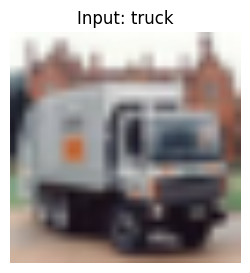

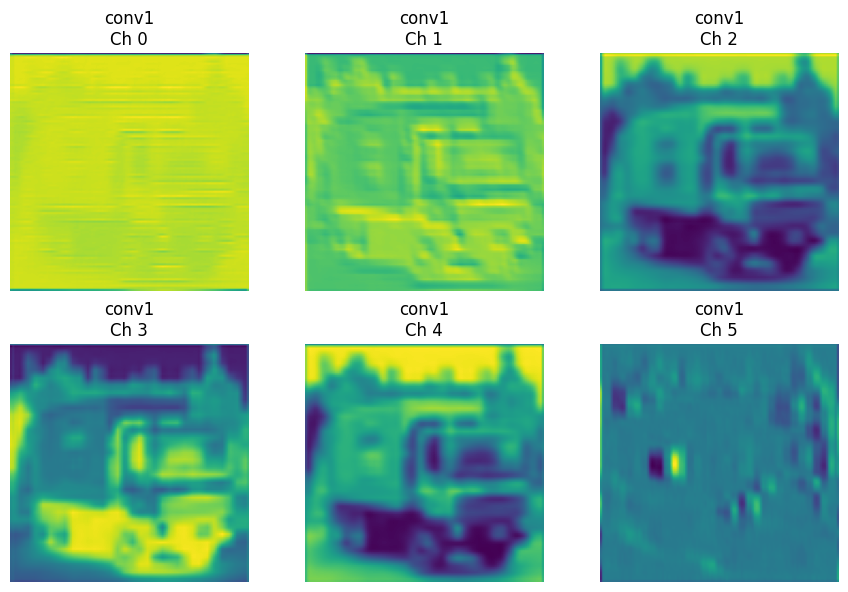

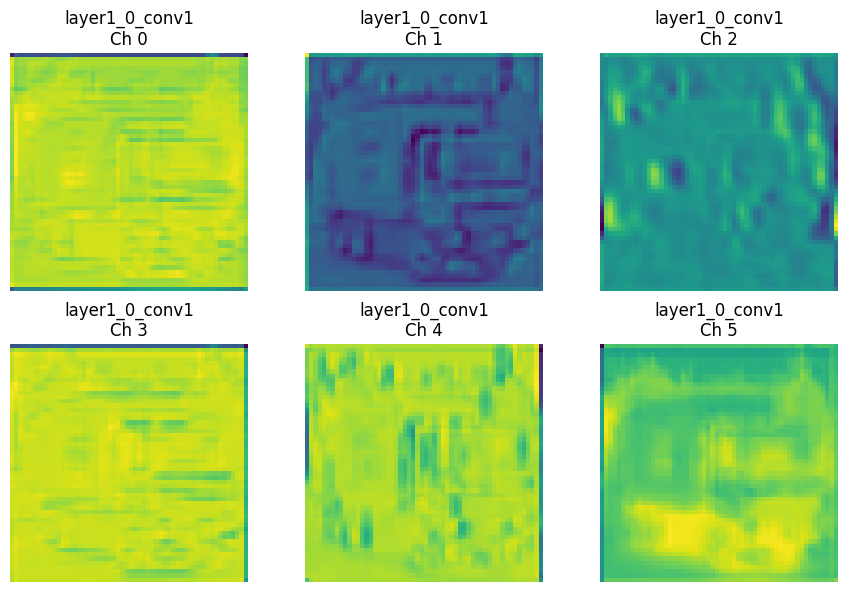

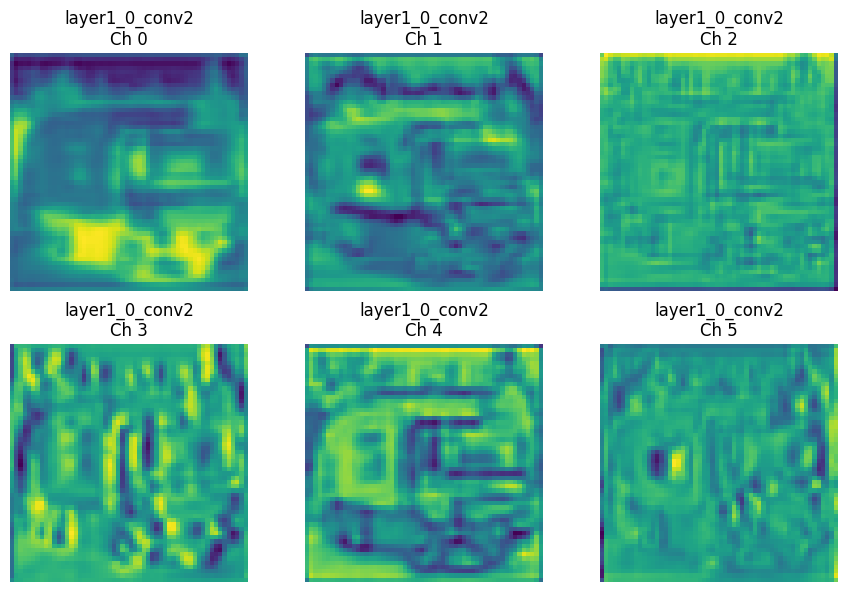

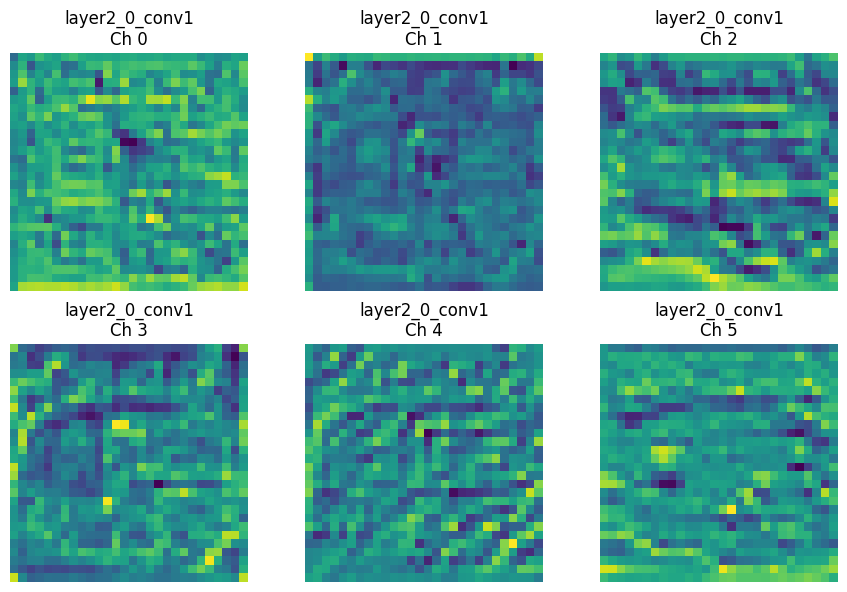

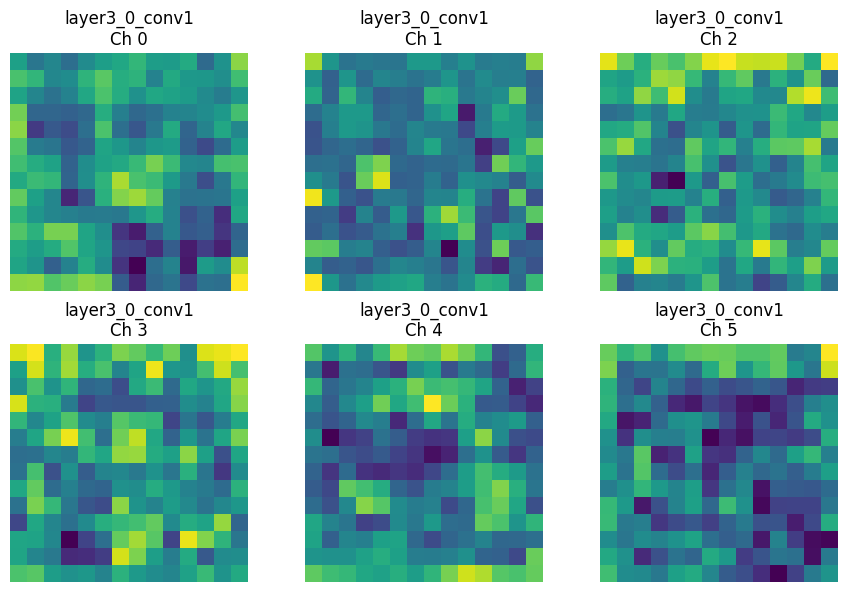

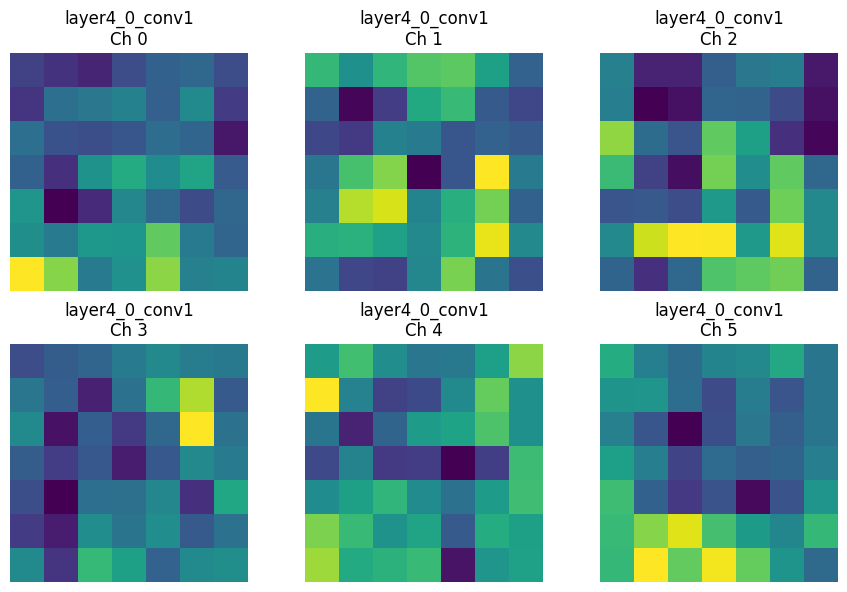

In [7]:
# 5. Prepare a dict to collect activations via forward hooks
feature_maps = {}
def get_hook(name):
    def hook(module, inp, outp):
        feature_maps[name] = outp.detach()
    return hook

# 6. Register hooks on 6 conv layers
resnet18.conv1.register_forward_hook(get_hook('conv1'))
resnet18.layer1[0].conv1.register_forward_hook(get_hook('layer1_0_conv1'))
resnet18.layer1[0].conv2.register_forward_hook(get_hook('layer1_0_conv2'))
resnet18.layer2[0].conv1.register_forward_hook(get_hook('layer2_0_conv1'))
resnet18.layer3[0].conv1.register_forward_hook(get_hook('layer3_0_conv1'))
resnet18.layer4[0].conv1.register_forward_hook(get_hook('layer4_0_conv1'))

# 7. Un-normalization helper for plotting
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)

# 8. Plotting helper for feature maps
def plot_feature_maps(act, layer_name, n_maps=6):
    """
    act: torch.Tensor of shape [1, C, H, W]
    """
    act = act.squeeze(0).cpu().numpy()  # [C, H, W]
    n_channels = act.shape[0]
    n = min(n_maps, n_channels)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(n_cols*3, n_rows*3))
    for i in range(n):
        fmap = act[i]
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-6)
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(fmap, cmap='viridis')
        plt.title(f'{layer_name}\nCh {i}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 9. Pick one sample image (e.g., first 'airplane')
classes = test_dataset.classes
sample_idx = next(i for i, (_, lbl) in enumerate(test_dataset) if lbl == randint(0,9))  # class 0 = 'airplane'
img, lbl = test_dataset[sample_idx]
print(f"Visualizing feature maps for a '{classes[lbl]}' image (idx={sample_idx})")

# 10. Forward pass & collect hooks
feature_maps.clear()
x = img.unsqueeze(0).to(device)
with torch.no_grad():
    _ = resnet18(x)   # no more fc → no device mismatch

# 11. Show original image
plt.figure(figsize=(3,3))
plt.imshow(unnormalize(img.to(device)).permute(1,2,0).cpu().numpy())
plt.title(f"Input: {classes[lbl]}")
plt.axis('off')
plt.show()

# 12. Plot first 6 feature maps for each hooked layer
for name in [
    'conv1',
    'layer1_0_conv1',
    'layer1_0_conv2',
    'layer2_0_conv1',
    'layer3_0_conv1',
    'layer4_0_conv1'
]:
    activation = feature_maps[name]  # [1, C, H, W]
    plot_feature_maps(activation, layer_name=name, n_maps=6)

### Version - 2

Files already downloaded and verified
Visualizing: 'bird' (class 2)


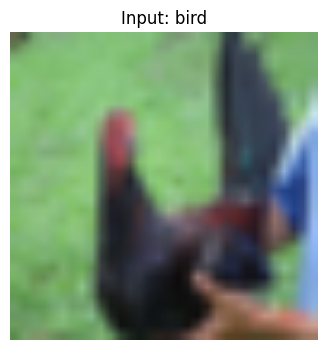

conv1_block shape: torch.Size([1, 64, 112, 112])


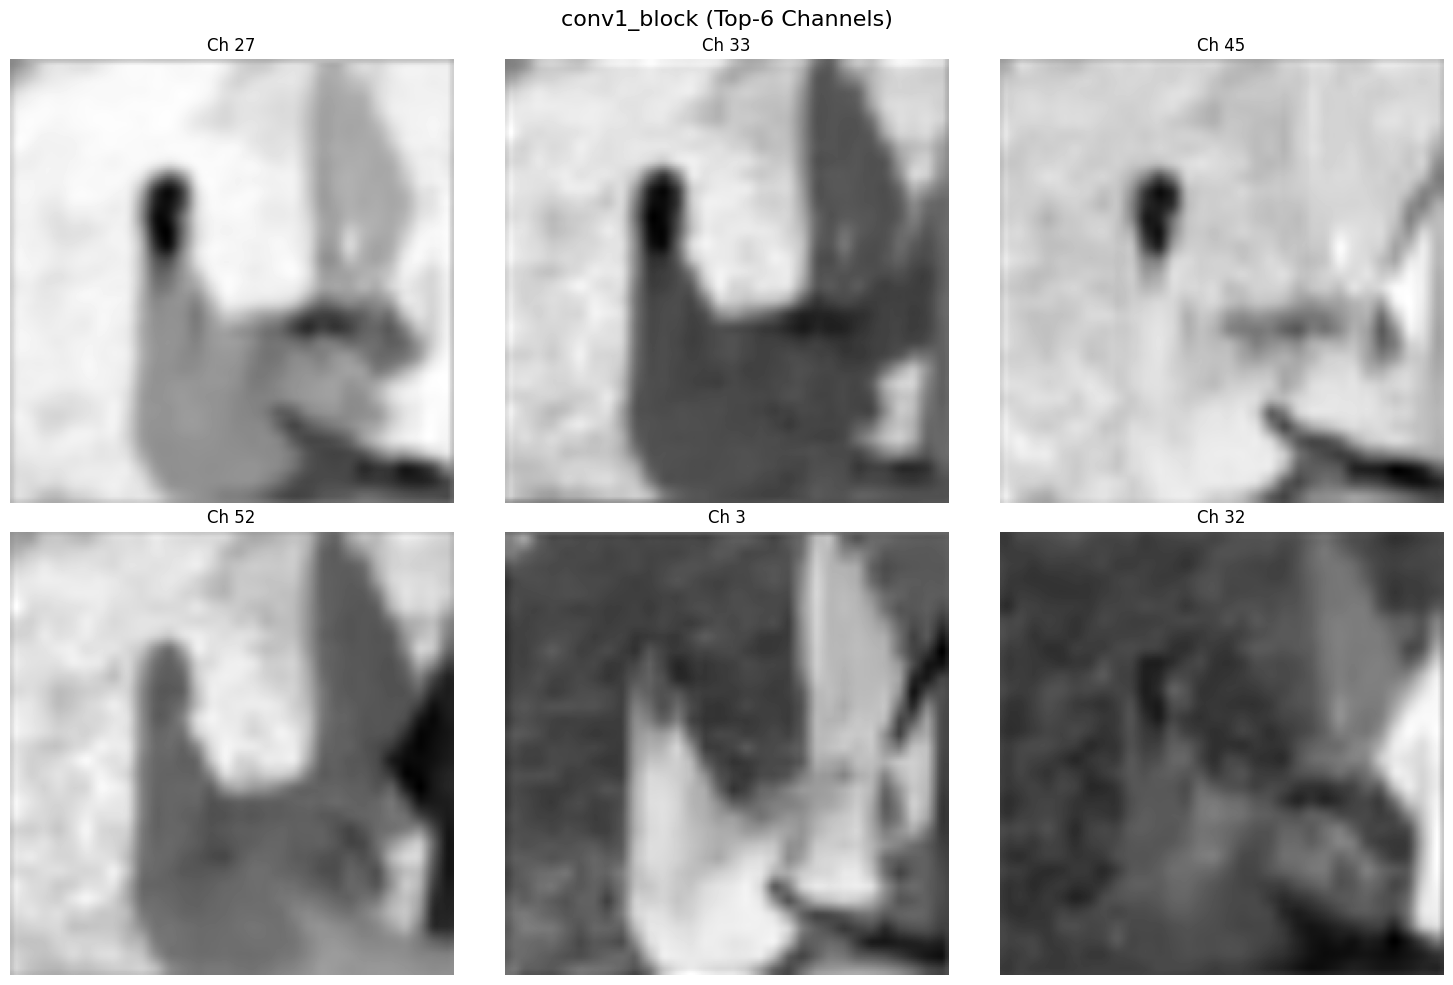

layer1_block shape: torch.Size([1, 64, 56, 56])


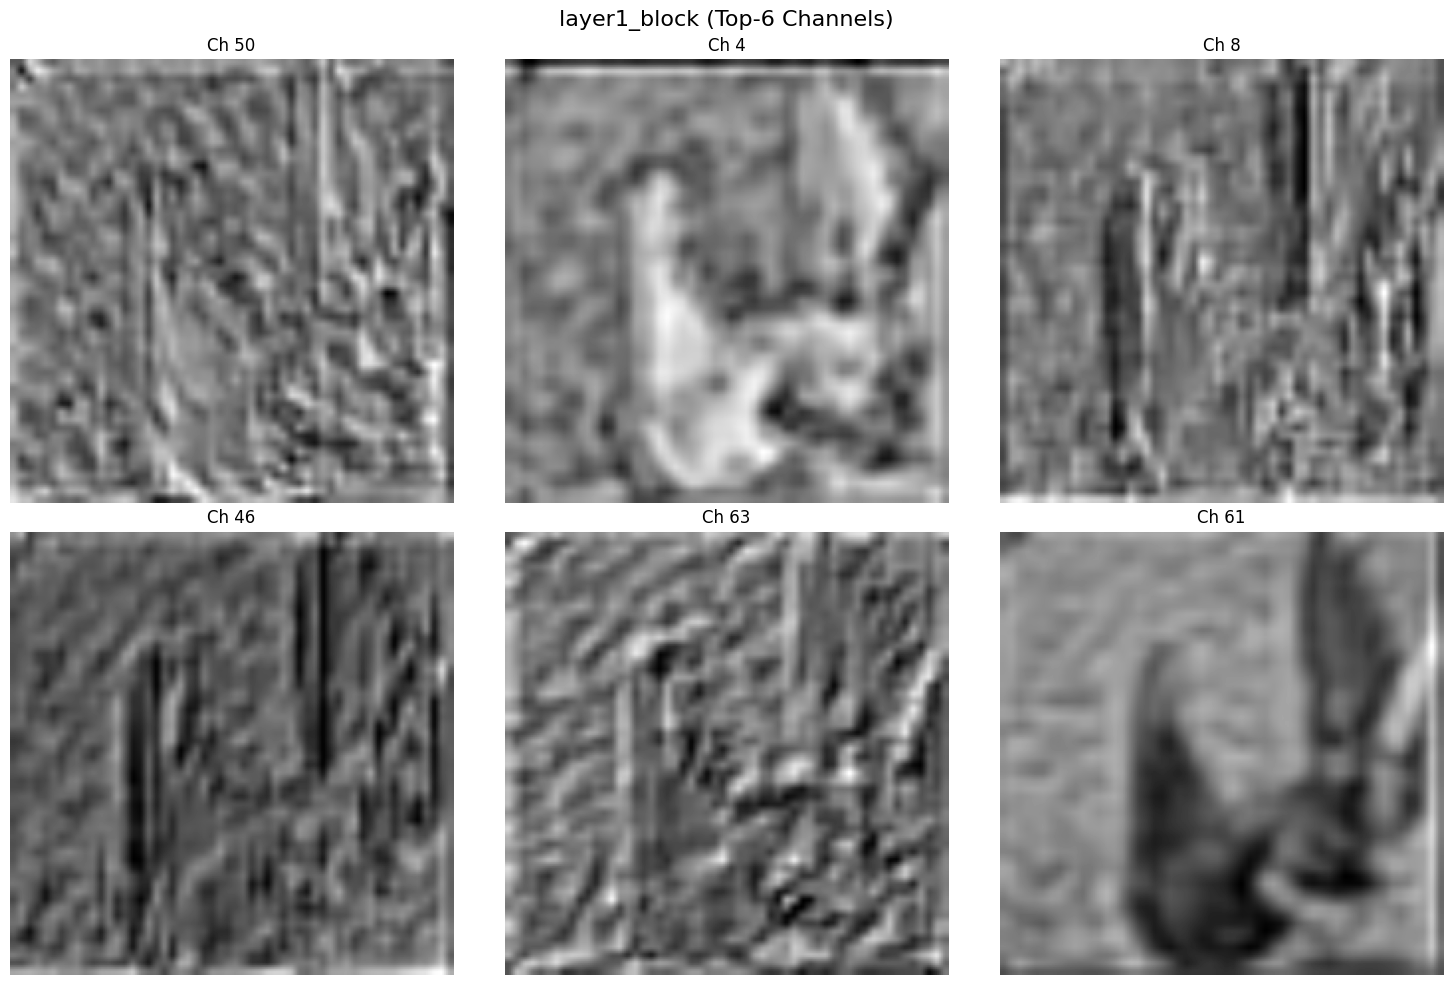

layer2_block shape: torch.Size([1, 128, 28, 28])


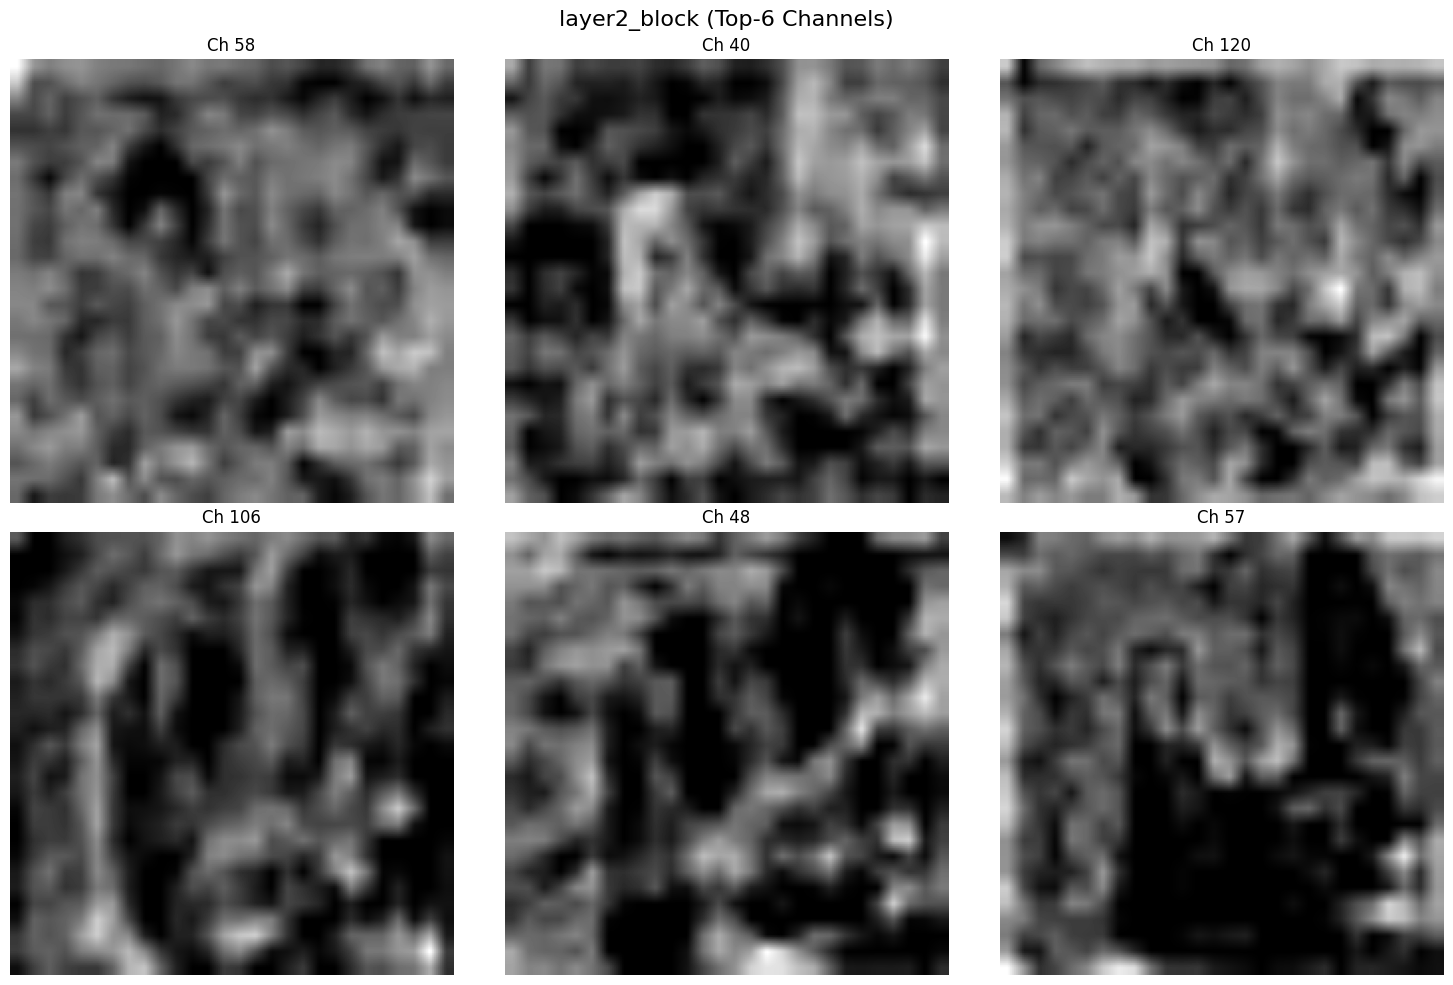

layer3_block shape: torch.Size([1, 256, 14, 14])


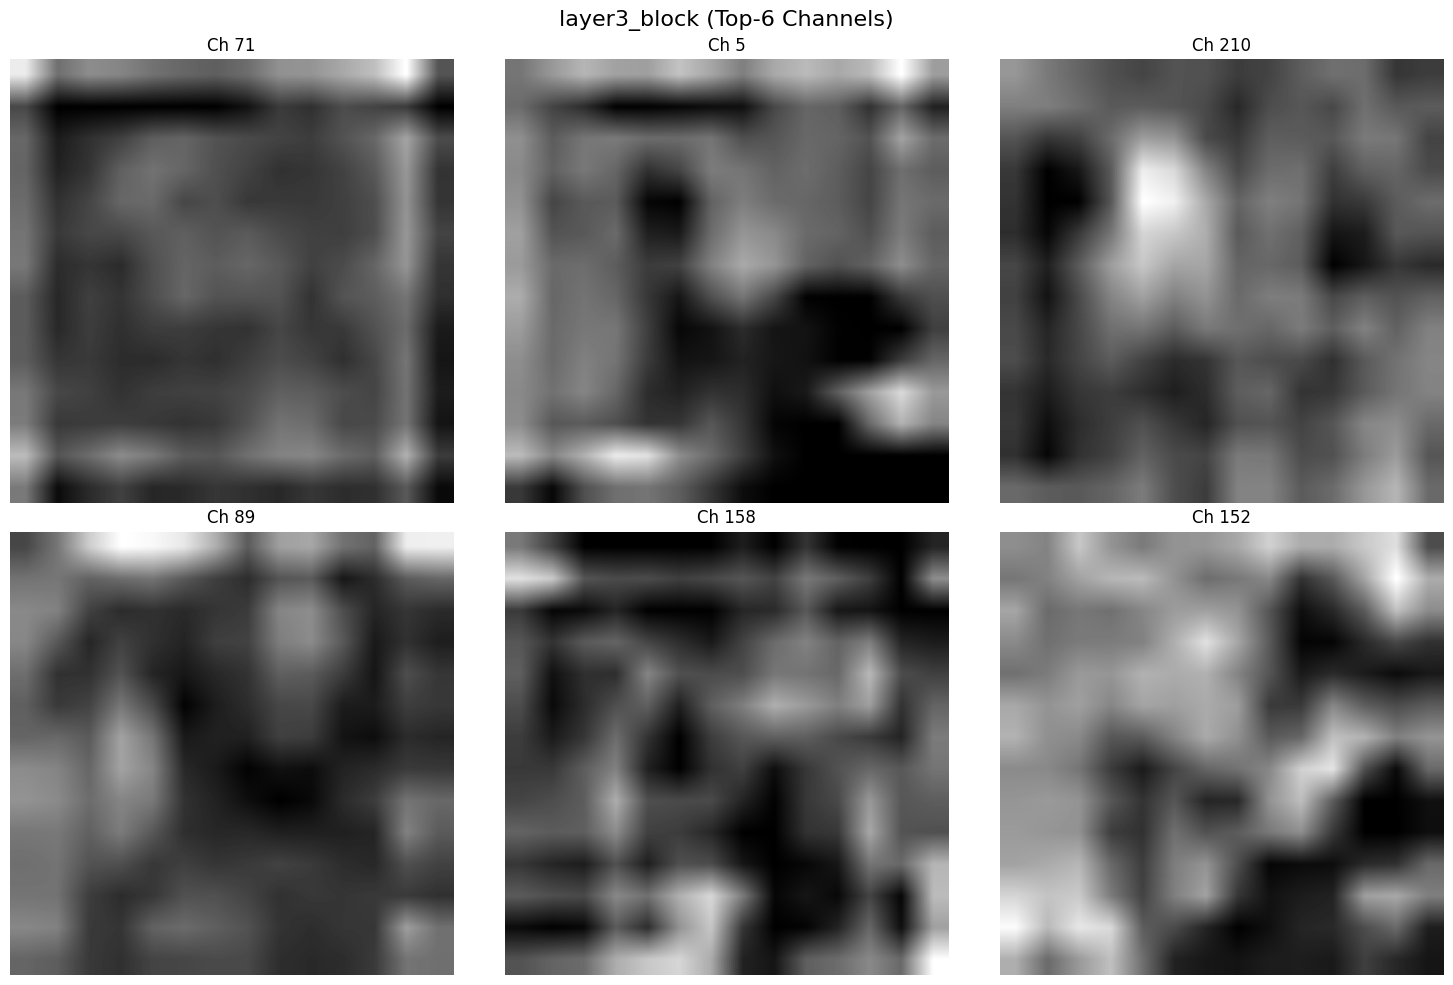

layer4_block shape: torch.Size([1, 512, 7, 7])


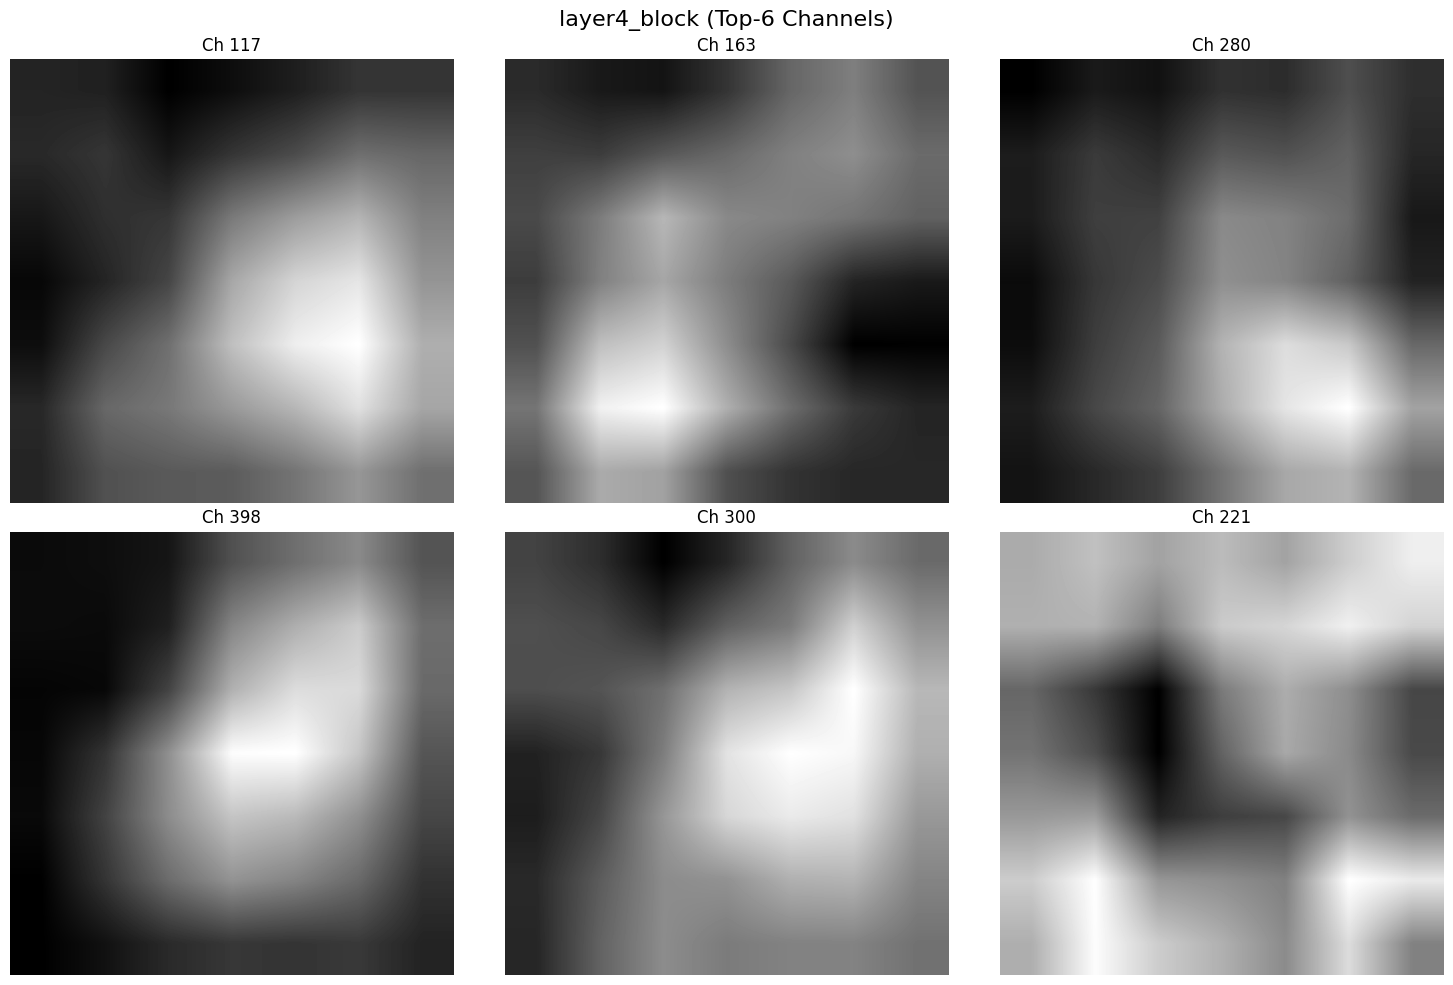

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from random import randint

# 1. Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Dataset with ImageNet normalization
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# 3. Load and modify ResNet-18
resnet18 = models.resnet18(pretrained=True).to(device)
resnet18.eval()
resnet18.fc = nn.Identity()  # Remove classification head

# 4. Hook setup for BLOCK OUTPUTS (not individual conv layers)
feature_maps = {}
def get_hook(name):
    def hook(_, __, outp):
        feature_maps[name] = outp.detach()
    return hook

# Register hooks on RESIDUAL BLOCK OUTPUTS (after skip connection and ReLU)
resnet18.conv1.register_forward_hook(get_hook('conv1_block'))  # First conv block
resnet18.layer1.register_forward_hook(get_hook('layer1_block'))  # Full layer1 output
resnet18.layer2.register_forward_hook(get_hook('layer2_block'))
resnet18.layer3.register_forward_hook(get_hook('layer3_block'))
resnet18.layer4.register_forward_hook(get_hook('layer4_block'))

# 5. Improved visualization with upscaling
def plot_feature_maps(activation, layer_name, n_maps=6, target_size=224):
    """Visualize feature maps with upscaling for deep layers"""
    # Select top-n_maps channels by mean activation
    channel_means = activation.squeeze(0).mean(dim=(1,2))
    top_channels = channel_means.argsort(descending=True)[:n_maps]
    act_top = activation[:, top_channels]
    
    # Upscale small feature maps
    if act_top.shape[-1] < target_size:
        act_top = F.interpolate(
            act_top, size=target_size, mode="bilinear", align_corners=False
        )
    
    act_top = act_top.squeeze(0).cpu().numpy()
    
    # Plotting
    n_cols = 3
    n_rows = int(np.ceil(n_maps / n_cols))
    plt.figure(figsize=(15, 5*n_rows))
    plt.suptitle(f"{layer_name} (Top-{n_maps} Channels)", fontsize=16)
    
    for i in range(n_maps):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(act_top[i], cmap='grey')
        plt.title(f"Ch {top_channels[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 6. Select a meaningful image (e.g., dog or cat)
class_idx = randint(0,9)  # Dog class in CIFAR-10
sample_idx = next(i for i, (_, lbl) in enumerate(test_dataset) if lbl == class_idx)
img, lbl = test_dataset[sample_idx]
classes = test_dataset.classes
print(f"Visualizing: '{classes[lbl]}' (class {lbl})")

# 7. Forward pass
feature_maps.clear()
with torch.no_grad():
    _ = resnet18(img.unsqueeze(0).to(device))
    
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)

# 8. Plot original image
plt.figure(figsize=(4,4))
plt.imshow(unnormalize(img.to(device)).permute(1,2,0).cpu().numpy())
plt.title(f"Input: {classes[lbl]}")
plt.axis('off')
plt.show()

# 9. Visualize feature maps with corrected hooks
for name in [
    'conv1_block', 
    'layer1_block',
    'layer2_block',
    'layer3_block',
    'layer4_block'
]:
    activation = feature_maps[name]
    print(f"{name} shape: {activation.shape}")
    plot_feature_maps(activation, layer_name=name, n_maps=6)